# Straight Pipe CFD Validation

This notebook validates the OpenFOAM straight-pipe CFD case used as the baseline for the hemodynamic model comparison project. The geometry is  simple: a straight circular pipe should produce Poiseuille-like laminar flow when driven at low Reynolds number.


## 1. Introduction

A straight cylindrical pipe is the reference geometry with steady, incompressible, laminar conditions. For a fully developed Newtonian flow, the axial velocity profile should be  parabolic, the pressure should decrease nearly linearly along the vessel, and the volumetric flow rate should be conserved between inlet, mid-vessel, and outlet sections.



In [1]:
from pathlib import Path
import re
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

%matplotlib inline

pd.set_option('display.precision', 6)
pd.set_option('display.max_columns', 20)

plt.rcParams.update({
    'figure.figsize': (7.2, 4.4),
    'axes.grid': True,
    'grid.alpha': 0.28,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.labelsize': 11,
    'axes.titlesize': 12,
    'legend.frameon': False,
})

REPO_ROOT = Path.cwd().resolve()
if REPO_ROOT.name == 'scripts':
    REPO_ROOT = REPO_ROOT.parent

PIPE_DIR = REPO_ROOT / 'openfoam' / 'pipe'
POST_DIR = PIPE_DIR / 'postProcessing'
PARAVIEW_DIR = REPO_ROOT / 'data_parafoam'
OUTPUT_DIR = REPO_ROOT / 'output' / 'pipe_v2'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

PIPE_DIR, POST_DIR, PARAVIEW_DIR, OUTPUT_DIR

(PosixPath('/home/gurovamr/OpenFOAM/gurovamr-dev/run/TrackModule2/Hemodynamics-Model-Comparison/openfoam/pipe'),
 PosixPath('/home/gurovamr/OpenFOAM/gurovamr-dev/run/TrackModule2/Hemodynamics-Model-Comparison/openfoam/pipe/postProcessing'),
 PosixPath('/home/gurovamr/OpenFOAM/gurovamr-dev/run/TrackModule2/Hemodynamics-Model-Comparison/data_parafoam'),
 PosixPath('/home/gurovamr/OpenFOAM/gurovamr-dev/run/TrackModule2/Hemodynamics-Model-Comparison/output/pipe_v2'))

## 2. Load Data

This section loads the OpenFOAM and ParaView outputs used throughout the validation workflow. Pressure values are handled explicitly in a dedicated subsection before the hydraulic resistance analysis to keep unit conventions transparent and reproducible.

In [2]:
def read_surface_field_value(path: Path) -> dict:
    """Read an OpenFOAM surfaceFieldValue.dat file with scalar or vector area averages."""
    if not path.exists():
        raise FileNotFoundError(path)

    area = np.nan
    header = None
    value_line = None
    for raw in path.read_text().splitlines():
        line = raw.strip()
        if not line:
            continue
        if line.startswith('# Area'):
            area = float(line.split(':', 1)[1].strip())
        elif line.startswith('# Time'):
            header = line.lstrip('#').strip().split()
        elif not line.startswith('#'):
            value_line = line

    if value_line is None:
        raise ValueError(f'No data row found in {path}')

    time_text, rest = value_line.split(maxsplit=1)
    if '(' in rest and ')' in rest:
        values = [float(v) for v in re.findall(r'[-+]?\d*\.?\d+(?:[eE][-+]?\d+)?', rest)]
        value = np.array(values, dtype=float)
    else:
        value = float(rest)

    return {'path': path, 'area_m2': area, 'time': float(time_text), 'value': value, 'header': header}


def read_xy_sample(path: Path) -> pd.DataFrame:
    """Read OpenFOAM sampled .xy files whose column names are stored in the comment header."""
    if not path.exists():
        raise FileNotFoundError(path)

    header = None
    for raw in path.read_text().splitlines():
        if raw.strip().startswith('#') and 'distance' in raw:
            header = raw.replace('#', ' ', 1).split()
            break
    if header is None:
        raise ValueError(f'Could not find column header in {path}')

    return pd.read_csv(path, comment='#', sep=r'\s+', names=header, engine='python')


def load_paraview_exports(directory: Path) -> dict:
    """Load ParaView CSV exports when they are present."""
    exports = {}
    for location in ['inlet', 'midslice', 'outlet']:
        slice_path = directory / f'{location}_integration.csv'
        integrated_path = directory / f'{location}_integration_variable.csv'
        exports[location] = {
            'slice': pd.read_csv(slice_path) if slice_path.exists() else pd.DataFrame(),
            'integrated': pd.read_csv(integrated_path) if integrated_path.exists() else pd.DataFrame(),
        }
    return exports


def parse_transport_nu(path: Path) -> float:
    text = path.read_text()
    match = re.search(r'\bnu\s+\[[^\]]+\]\s+([-+]?\d*\.?\d+(?:[eE][-+]?\d+)?)', text)
    if not match:
        raise ValueError(f'Could not parse nu from {path}')
    return float(match.group(1))


def geometry_from_block_mesh(path: Path) -> dict:
    text = path.read_text()
    radius_match = re.search(r'Radius\s+R\s+=\s+([0-9.eE+-]+)\s*m', text)
    length_match = re.search(r'Length\s+L\s+=\s+([0-9.eE+-]+)\s*m', text)
    if radius_match and length_match:
        radius = float(radius_match.group(1))
        length = float(length_match.group(1))
    else:
        vertices = re.findall(r'\(\s*([-+0-9.eE]+)\s+([-+0-9.eE]+)\s+([-+0-9.eE]+)\s*\)', text)
        xyz = np.array(vertices, dtype=float)
        radius = float(np.max(np.hypot(xyz[:, 0], xyz[:, 1])))
        length = float(np.max(xyz[:, 2]) - np.min(xyz[:, 2]))
    return {'radius_m': radius, 'diameter_m': 2 * radius, 'length_m': length, 'area_m2': np.pi * radius**2}


def pressure_to_pa(p_kinematic, rho):
    return np.asarray(p_kinematic, dtype=float) * rho

In [3]:
rho = 1060.0  # kg/m^3, blood density used for dynamic pressure conversion
nu = parse_transport_nu(PIPE_DIR / 'constant' / 'transportProperties')
mu = rho * nu
geometry = geometry_from_block_mesh(PIPE_DIR / 'system' / 'blockMeshDict')

centreline = read_xy_sample(POST_DIR / 'sampleDict' / '144' / 'centreline.xy')
outlet_radial = read_xy_sample(POST_DIR / 'sampleDict' / '144' / 'outletRadial.xy')
paraview_exports = load_paraview_exports(PARAVIEW_DIR)

patch = {
    'inlet_U': read_surface_field_value(POST_DIR / 'patchAverage(patch=inlet,fields=(U))' / '144' / 'surfaceFieldValue.dat'),
    'outlet_U': read_surface_field_value(POST_DIR / 'patchAverage(patch=outlet,fields=(U))' / '144' / 'surfaceFieldValue.dat'),
    'inlet_p': read_surface_field_value(POST_DIR / 'patchAverage(patch=inlet,fields=(p))' / '144' / 'surfaceFieldValue.dat'),
    'outlet_p': read_surface_field_value(POST_DIR / 'patchAverage(patch=outlet,fields=(p))' / '144' / 'surfaceFieldValue.dat'),
}

case_summary = pd.DataFrame({
    'quantity': ['density rho', 'kinematic viscosity nu', 'dynamic viscosity mu', 'radius', 'diameter', 'length', 'analytical area'],
    'value': [rho, nu, mu, geometry['radius_m'], geometry['diameter_m'], geometry['length_m'], geometry['area_m2']],
    'units': ['kg/m^3', 'm^2/s', 'Pa s', 'm', 'm', 'm', 'm^2'],
})
display(case_summary)

loaded_summary = pd.DataFrame([
    {'dataset': 'centreline.xy', 'rows': len(centreline), 'columns': ', '.join(centreline.columns)},
    {'dataset': 'outletRadial.xy', 'rows': len(outlet_radial), 'columns': ', '.join(outlet_radial.columns)},
    *[
        {'dataset': f'ParaView {loc} slice CSV', 'rows': len(items['slice']), 'columns': ', '.join(items['slice'].columns)}
        for loc, items in paraview_exports.items()
    ],
    *[
        {'dataset': f'ParaView {loc} integrated CSV', 'rows': len(items['integrated']), 'columns': ', '.join(items['integrated'].columns)}
        for loc, items in paraview_exports.items()
    ],
])
display(loaded_summary)

,quantity,value,units
0,density rho,1060.000000,kg/m^3
1,kinematic viscosity nu,0.000003,m^2/s
2,dynamic viscosity mu,0.003500,Pa s
3,radius,0.002000,m
4,diameter,0.004000,m
5,length,0.040000,m
6,analytical area,0.000013,m^2


,dataset,rows,columns
0,centreline.xy,200,"distance, x, y, z, U_x, U_y, U_z, p"
1,outletRadial.xy,100,"distance, x, y, z, U_x, U_y, U_z, p"
2,ParaView inlet slice CSV,1545,"U:0, U:1, U:2, p, Cell Type"
3,ParaView midslice slice CSV,994,"U:0, U:1, U:2, p, Cell Type"
4,ParaView outlet slice CSV,1447,"U:0, U:1, U:2, p, Cell Type"
5,ParaView inlet integrated CSV,1,"U:0, U:1, U:2, p, Area, Cell Type"
6,ParaView midslice integrated CSV,1,"U:0, U:1, U:2, p, Area, Cell Type"
7,ParaView outlet integrated CSV,1,"U:0, U:1, U:2, p, Area, Cell Type"


## 3. Flow Rate Analysis

The inlet and outlet flow rates are computed from area-averaged axial velocity and patch area. A mid-vessel estimate is included from the sampled velocity profile by using the Poiseuille relation `U_mean = U_max / 2`.

In [4]:
radius = geometry['radius_m']
diameter = geometry['diameter_m']
length = geometry['length_m']
area_patch = patch['outlet_U']['area_m2']
area_analytical = geometry['area_m2']

u_inlet = float(patch['inlet_U']['value'][2])
u_outlet = float(patch['outlet_U']['value'][2])
q_inlet = u_inlet * patch['inlet_U']['area_m2']
q_outlet = u_outlet * patch['outlet_U']['area_m2']

mid_row = centreline.iloc[(centreline['z'] - length / 2).abs().idxmin()]
u_mid_centerline = float(mid_row['U_z'])
u_mid_mean_poiseuille = u_mid_centerline / 2.0
q_mid = u_mid_mean_poiseuille * area_patch

flow_summary = pd.DataFrame({
    'location': ['inlet', 'mid-vessel', 'outlet'],
    'area_m2': [patch['inlet_U']['area_m2'], area_patch, patch['outlet_U']['area_m2']],
    'characteristic_U_m_per_s': [u_inlet, u_mid_mean_poiseuille, u_outlet],
    'Q_m3_per_s': [q_inlet, q_mid, q_outlet],
})
flow_summary['relative_to_outlet_percent'] = 100 * (flow_summary['Q_m3_per_s'] - q_outlet) / q_outlet

display(flow_summary)

q_spread_percent = 100 * (flow_summary['Q_m3_per_s'].max() - flow_summary['Q_m3_per_s'].min()) / flow_summary['Q_m3_per_s'].mean()
display(pd.DataFrame({
    'check': ['Q spread across inlet/mid/outlet'],
    'value_percent': [q_spread_percent],
    'interpretation': ['Small spread supports approximate conservation.'],
}))

,location,area_m2,characteristic_U_m_per_s,Q_m3_per_s,relative_to_outlet_percent
0,inlet,0.000013,0.100780,0.000001,-0.000008
1,mid-vessel,0.000013,0.100027,0.000001,-0.747744
2,outlet,0.000013,0.100780,0.000001,0.000000


,check,value_percent,interpretation
0,Q spread across inlet/mid/outlet,0.749612,Small spread supports approximate conservation.


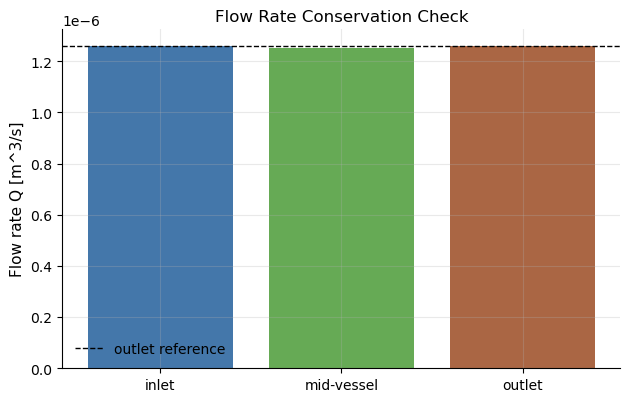

In [5]:
fig, ax = plt.subplots()
ax.bar(flow_summary['location'], flow_summary['Q_m3_per_s'], color=['#4477AA', '#66AA55', '#AA6644'])
ax.axhline(q_outlet, color='black', linewidth=1, linestyle='--', label='outlet reference')
ax.set_ylabel('Flow rate Q [m^3/s]')
ax.set_title('Flow Rate Conservation Check')
ax.legend()
plt.show()

## 4. Pressure Drop Analysis

The pressure drop is computed from area-averaged inlet and outlet pressures. The sampled centreline data are also used to inspect pressure evolution along the vessel. A nearly linear pressure-position curve is expected for fully developed laminar pipe flow.

In [6]:
p_inlet_pa = float(pressure_to_pa(patch['inlet_p']['value'], rho))
p_outlet_pa = float(pressure_to_pa(patch['outlet_p']['value'], rho))
delta_p_patch = p_inlet_pa - p_outlet_pa

pressure_line = centreline.copy()
pressure_line['p_Pa'] = pressure_to_pa(pressure_line['p'], rho)
pressure_fit = np.polyfit(pressure_line['z'], pressure_line['p_Pa'], 1)
pressure_line['p_fit_Pa'] = np.polyval(pressure_fit, pressure_line['z'])
ss_res = np.sum((pressure_line['p_Pa'] - pressure_line['p_fit_Pa'])**2)
ss_tot = np.sum((pressure_line['p_Pa'] - pressure_line['p_Pa'].mean())**2)
pressure_r2 = 1 - ss_res / ss_tot
centreline_delta_p = pressure_line['p_Pa'].iloc[0] - pressure_line['p_Pa'].iloc[-1]

pressure_summary = pd.DataFrame({
    'quantity': ['P_inlet', 'P_outlet', 'DeltaP patch', 'DeltaP centreline', 'centreline dP/dz', 'linear fit R2'],
    'value': [p_inlet_pa, p_outlet_pa, delta_p_patch, centreline_delta_p, pressure_fit[0], pressure_r2],
    'units': ['Pa', 'Pa', 'Pa', 'Pa', 'Pa/m', '-'],
})
display(pressure_summary)

,quantity,value,units
0,P_inlet,28.497419,Pa
1,P_outlet,0.000000,Pa
2,DeltaP patch,28.497419,Pa
3,DeltaP centreline,27.234824,Pa
4,centreline dP/dz,-711.955310,Pa/m
5,linear fit R2,0.999991,-


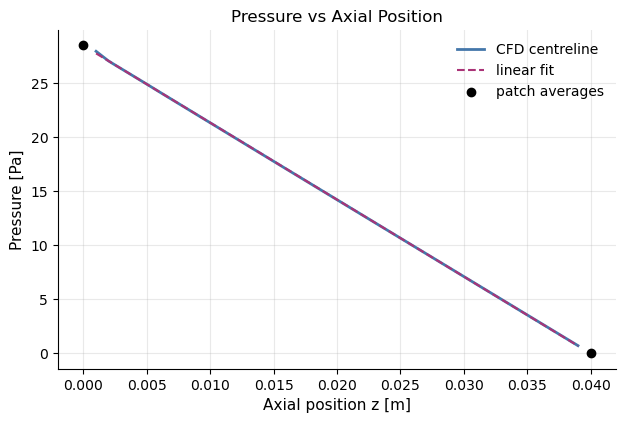

In [7]:
fig, ax = plt.subplots()
ax.plot(pressure_line['z'], pressure_line['p_Pa'], color='#4477AA', linewidth=2, label='CFD centreline')
ax.plot(pressure_line['z'], pressure_line['p_fit_Pa'], color='#AA3377', linestyle='--', label='linear fit')
ax.scatter([0, length], [p_inlet_pa, p_outlet_pa], color='black', zorder=3, label='patch averages')
ax.set_xlabel('Axial position z [m]')
ax.set_ylabel('Pressure [Pa]')
ax.set_title('Pressure vs Axial Position')
ax.legend()
plt.show()

## 5. Velocity Analysis

For a laminar straight pipe, the fully developed velocity profile should be approximately parabolic. The sampled radial profile is compared with an ideal parabolic profile using the CFD mean flow rate as the reference mean velocity.

In [8]:
profile = outlet_radial.copy()
profile['radius_signed_m'] = profile['x']
profile['radius_abs_m'] = np.abs(profile['x'])
profile['U_axial_m_per_s'] = profile['U_z']
profile['U_mag_m_per_s'] = np.sqrt(profile['U_x']**2 + profile['U_y']**2 + profile['U_z']**2)

u_mean_cfd = q_outlet / area_patch
u_max_profile = float(profile['U_axial_m_per_s'].max())
u_mean_profile_est = u_max_profile / 2.0
profile['U_poiseuille_m_per_s'] = 2 * u_mean_cfd * (1 - (profile['radius_abs_m'] / radius)**2)
profile['U_poiseuille_m_per_s'] = profile['U_poiseuille_m_per_s'].clip(lower=0)
profile_rmse = float(np.sqrt(np.mean((profile['U_axial_m_per_s'] - profile['U_poiseuille_m_per_s'])**2)))
profile_rmse_percent = 100 * profile_rmse / max(u_max_profile, np.finfo(float).eps)

velocity_summary = pd.DataFrame({
    'quantity': ['mean velocity from Q/A', 'max sampled axial velocity', 'profile-based mean estimate Umax/2', 'Umax / Umean', 'profile RMSE vs parabolic', 'profile RMSE / Umax'],
    'value': [u_mean_cfd, u_max_profile, u_mean_profile_est, u_max_profile / u_mean_cfd, profile_rmse, profile_rmse_percent],
    'units': ['m/s', 'm/s', 'm/s', '-', 'm/s', '%'],
})
display(velocity_summary)

display(profile[['radius_signed_m', 'U_axial_m_per_s', 'U_poiseuille_m_per_s', 'p']].head())

,quantity,value,units
0,mean velocity from Q/A,0.100780,m/s
1,max sampled axial velocity,0.199954,m/s
2,profile-based mean estimate Umax/2,0.099977,m/s
3,Umax / Umean,1.984060,-
4,profile RMSE vs parabolic,0.001532,m/s
5,profile RMSE / Umax,0.766384,%


,radius_signed_m,U_axial_m_per_s,U_poiseuille_m_per_s,p
0,-0.002000,0.000000,0.000000,0.00134
1,-0.001960,0.007679,0.008062,0.00134
2,-0.001919,0.015358,0.015959,0.00134
3,-0.001879,0.023037,0.023691,0.00134
4,-0.001838,0.030716,0.031259,0.00134


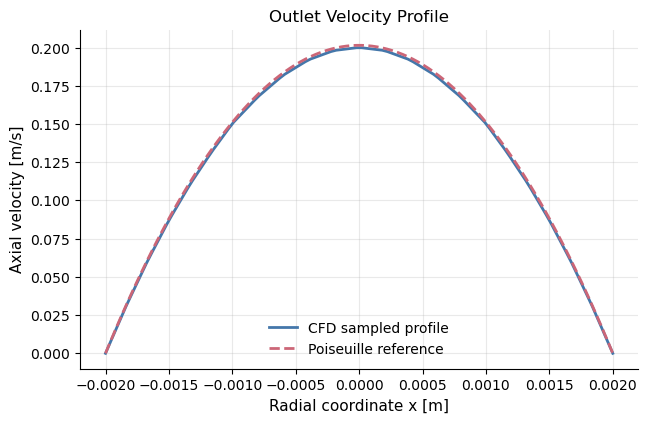

In [9]:
fig, ax = plt.subplots()
ax.plot(profile['radius_signed_m'], profile['U_axial_m_per_s'], color='#4477AA', linewidth=2, label='CFD sampled profile')
ax.plot(profile['radius_signed_m'], profile['U_poiseuille_m_per_s'], color='#CC6677', linestyle='--', linewidth=2, label='Poiseuille reference')
ax.set_xlabel('Radial coordinate x [m]')
ax.set_ylabel('Axial velocity [m/s]')
ax.set_title('Outlet Velocity Profile')
ax.legend()
plt.show()

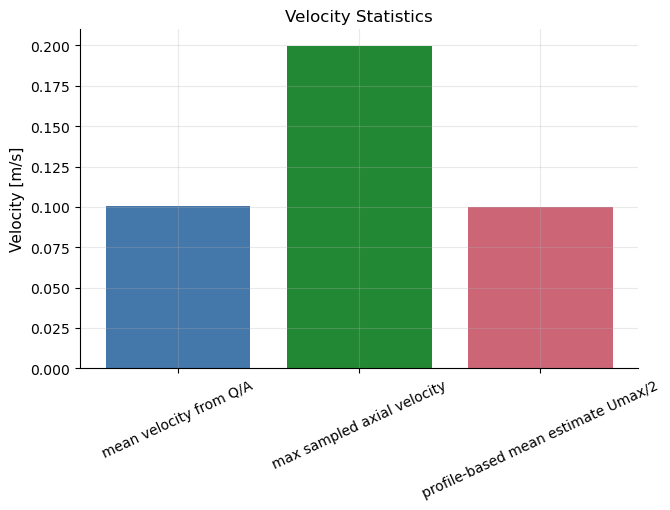

In [10]:
velocity_plot_summary = velocity_summary[velocity_summary['quantity'].isin([
    'mean velocity from Q/A', 'max sampled axial velocity', 'profile-based mean estimate Umax/2'
])].copy()

fig, ax = plt.subplots()
ax.bar(velocity_plot_summary['quantity'], velocity_plot_summary['value'], color=['#4477AA', '#228833', '#CC6677'])
ax.set_ylabel('Velocity [m/s]')
ax.set_title('Velocity Statistics')
ax.tick_params(axis='x', rotation=25)
plt.show()

## 6. Reynolds Number

The Reynolds number is computed as

`Re = (rho * U * D) / mu`,

where `rho` is density, `mu` is dynamic viscosity, `U` is the characteristic mean velocity, and `D` is pipe diameter. For this validation case the characteristic velocity is the outlet mean velocity computed from `Q/A`.

In [11]:
reynolds = rho * u_mean_cfd * diameter / mu
reynolds_alt = u_mean_cfd * diameter / nu

re_summary = pd.DataFrame({
    'quantity': ['rho', 'mu', 'nu', 'characteristic velocity U', 'diameter D', 'Re = rho U D / mu', 'Re = U D / nu'],
    'value': [rho, mu, nu, u_mean_cfd, diameter, reynolds, reynolds_alt],
    'units': ['kg/m^3', 'Pa s', 'm^2/s', 'm/s', 'm', '-', '-'],
})
display(re_summary)

display(Markdown(f'**Laminar assessment:** Re = {reynolds:.1f}, which is well below the usual pipe-flow transition range, so laminar Poiseuille-like behavior is expected.'))

,quantity,value,units
0,rho,1060.000000,kg/m^3
1,mu,0.003500,Pa s
2,nu,0.000003,m^2/s
3,characteristic velocity U,0.100780,m/s
4,diameter D,0.004000,m
5,Re = rho U D / mu,122.088053,-
6,Re = U D / nu,122.088053,-


**Laminar assessment:** Re = 122.1, which is well below the usual pipe-flow transition range, so laminar Poiseuille-like behavior is expected.

### OpenFOAM Pressure Unit Convention

In incompressible OpenFOAM solvers, pressure is typically stored as **kinematic pressure**:

- $p_{\mathrm{kinematic}}$ units: $\mathrm{m^2/s^2}$
- physical pressure $p_{\mathrm{physical}}$ units: $\mathrm{Pa}$

The conversion used in this notebook is:

$$
p_{\mathrm{physical}} = \rho\, p_{\mathrm{kinematic}}
$$

For this straight-pipe workflow, the imported OpenFOAM/ParaView pressure values are treated as kinematic pressure, and multiplication by density is applied explicitly inside the notebook via `pressure_to_pa(...)`.

This convention is critical for reproducibility because an incorrect conversion would directly change:

- pressure drop $\Delta P$,
- hydraulic resistance $R = \Delta P/Q$,
- wall shear stress estimates based on pressure gradients.

## 7. Hydraulic Resistance

The CFD resistance is computed from the patch pressure drop and outlet flow rate:

`R_CFD = DeltaP / Q`.

The analytical Poiseuille resistance for a straight circular pipe is

`R = (8 * mu * L) / (pi * r^4)`.

In [12]:
r_cfd = delta_p_patch / q_outlet
r_theory = 8 * mu * length / (np.pi * radius**4)
q_theory = delta_p_patch / r_theory
percent_difference = 100 * (r_cfd - r_theory) / r_theory

resistance_summary = pd.DataFrame({
    'quantity': ['R_CFD', 'R_Poiseuille', 'percentage difference', 'Q implied by Poiseuille at CFD DeltaP'],
    'value': [r_cfd, r_theory, percent_difference, q_theory],
    'units': ['Pa s / m^3', 'Pa s / m^3', '%', 'm^3/s'],
})
display(resistance_summary)

,quantity,value,units
0,R_CFD,2.259713e+07,Pa s / m^3
1,R_Poiseuille,2.228169e+07,Pa s / m^3
2,percentage difference,1.415665e+00,%
3,Q implied by Poiseuille at CFD DeltaP,1.278961e-06,m^3/s


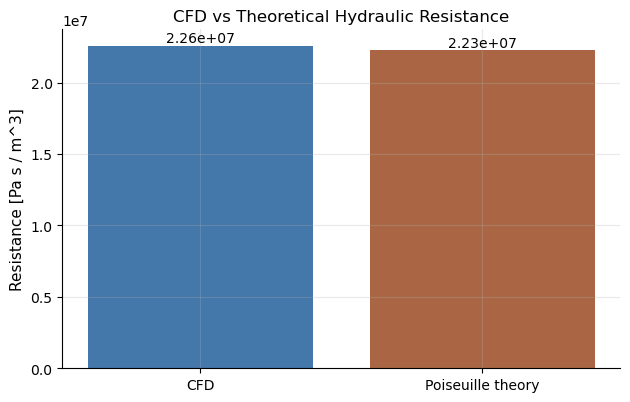

In [13]:
resistance_plot = pd.DataFrame({
    'model': ['CFD', 'Poiseuille theory'],
    'resistance_Pa_s_per_m3': [r_cfd, r_theory],
})

fig, ax = plt.subplots()
ax.bar(resistance_plot['model'], resistance_plot['resistance_Pa_s_per_m3'], color=['#4477AA', '#AA6644'])
ax.set_ylabel('Resistance [Pa s / m^3]')
ax.set_title('CFD vs Theoretical Hydraulic Resistance')
for i, value in enumerate(resistance_plot['resistance_Pa_s_per_m3']):
    ax.text(i, value, f'{value:.2e}', ha='center', va='bottom')
plt.show()

## Wall Shear Stress Validation

For laminar fully developed flow in a straight circular pipe, theoretical wall shear stress can be evaluated from flow rate:

$$
\tau_w = \frac{4\,\mu\,Q}{\pi R^3}
$$

and equivalently from pressure drop:

$$
\tau_w = \frac{\Delta P\,R}{2L}
$$

OpenFOAM incompressible `wallShearStress` output is kinematic (m²/s²), so it is converted to physical wall shear stress (Pa) with `tau_w = rho * tau_w_kinematic` before comparison with theory.

The code below computes both theoretical forms, then compares against CFD wall shear stress extracted from OpenFOAM post-processing when available. If direct wall shear stress output is unavailable, the CFD estimate falls back to pressure-gradient-based evaluation.

In [14]:
tau_w_theory_q = 4 * mu * q_outlet / (np.pi * radius**3)
tau_w_theory_dp = delta_p_patch * radius / (2 * length)

wss_path = POST_DIR / 'wallShearStress' / '144' / 'wallShearStress.dat'
if wss_path.exists():
    wss_lines = [ln.strip() for ln in wss_path.read_text().splitlines() if ln.strip() and not ln.strip().startswith('#')]
    if not wss_lines:
        raise ValueError(f'No wall shear stress data rows found in {wss_path}')
    wss_last = wss_lines[-1]
    # Parse min/max vectors from the OpenFOAM wallShearStress function object output.
    vec_values = [float(v) for v in re.findall(r'[-+]?\d*\.?\d+(?:[eE][-+]?\d+)?', wss_last)][1:7]
    if len(vec_values) >= 6:
        wss_min_vec = np.array(vec_values[:3], dtype=float)
        wss_max_vec = np.array(vec_values[3:6], dtype=float)
        tau_w_cfd_kinematic = float(np.mean([np.linalg.norm(wss_min_vec), np.linalg.norm(wss_max_vec)]))
        tau_w_cfd_kinematic_source = 'OpenFOAM wallShearStress min/max magnitudes (mean)'
    else:
        tau_w_cfd_kinematic = float(delta_p_patch * radius / (2 * length)) / rho
        tau_w_cfd_kinematic_source = 'Fallback from pressure gradient (insufficient vector parse)'
else:
    tau_w_cfd_kinematic = float(delta_p_patch * radius / (2 * length)) / rho
    tau_w_cfd_kinematic_source = 'Fallback from pressure gradient (file not found)'

tau_w_cfd = rho * tau_w_cfd_kinematic
tau_w_cfd_source = (
    'OpenFOAM incompressible wallShearStress is kinematic and was converted using rho. '
    + f'Raw source: {tau_w_cfd_kinematic_source}'
)

tau_w_reference = tau_w_theory_q
tau_w_abs_diff = abs(tau_w_cfd - tau_w_reference)
tau_w_pct_diff = 100 * tau_w_abs_diff / max(abs(tau_w_reference), np.finfo(float).eps)

wss_summary = pd.DataFrame({
    'quantity': [
        'tau_w_theory_from_Q',
        'tau_w_theory_from_DeltaP',
        'tau_w_CFD_kinematic_raw',
        'tau_w_CFD_physical',
        'absolute_difference_vs_theoryQ',
        'percent_difference_vs_theoryQ',
    ],
    'value': [
        tau_w_theory_q,
        tau_w_theory_dp,
        tau_w_cfd_kinematic,
        tau_w_cfd,
        tau_w_abs_diff,
        tau_w_pct_diff,
    ],
    'units': ['Pa', 'Pa', 'm^2/s^2', 'Pa', 'Pa', '%'],
    'source_or_note': [
        'Analytical laminar expression using Q',
        'Analytical consistency expression using DeltaP',
        tau_w_cfd_kinematic_source,
        tau_w_cfd_source,
        'abs(tau_w_CFD_physical - tau_w_theory_from_Q)',
        '100 * abs diff / |tau_w_theory_from_Q|',
    ],
})

wss_comparison = pd.DataFrame({
    'model': ['Theory (from Q)', 'CFD (physical from converted kinematic)'],
    'tau_w_Pa': [tau_w_theory_q, tau_w_cfd],
})

display(wss_summary)
print(f'WSS CFD kinematic source: {tau_w_cfd_kinematic_source}')
print('OpenFOAM incompressible wallShearStress is kinematic and was converted to Pa using tau_w = rho * tau_w_kinematic.')

,quantity,value,units,source_or_note
0,tau_w_theory_from_Q,0.702491,Pa,Analytical laminar expression using Q
1,tau_w_theory_from_DeltaP,0.712435,Pa,Analytical consistency expression using DeltaP
2,tau_w_CFD_kinematic_raw,0.000672,m^2/s^2,OpenFOAM wallShearStress min/max magnitudes (m...
3,tau_w_CFD_physical,0.711934,Pa,OpenFOAM incompressible wallShearStress is kin...
4,absolute_difference_vs_theoryQ,0.009443,Pa,abs(tau_w_CFD_physical - tau_w_theory_from_Q)
5,percent_difference_vs_theoryQ,1.344243,%,100 * abs diff / |tau_w_theory_from_Q|


WSS CFD kinematic source: OpenFOAM wallShearStress min/max magnitudes (mean)
OpenFOAM incompressible wallShearStress is kinematic and was converted to Pa using tau_w = rho * tau_w_kinematic.


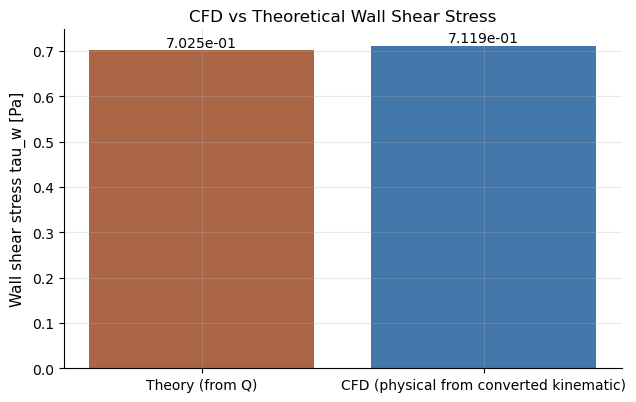

In [15]:
fig, ax = plt.subplots()
ax.bar(wss_comparison['model'], wss_comparison['tau_w_Pa'], color=['#AA6644', '#4477AA'])
ax.set_ylabel('Wall shear stress tau_w [Pa]')
ax.set_title('CFD vs Theoretical Wall Shear Stress')
for i, value in enumerate(wss_comparison['tau_w_Pa']):
    ax.text(i, value, f'{value:.3e}', ha='center', va='bottom')
plt.show()

In [16]:
if tau_w_pct_diff < 10:
    wss_interpretation = 'After converting OpenFOAM kinematic wallShearStress to Pa, CFD and theory are in strong agreement, indicating expected viscous wall behavior for laminar pipe flow.'
elif tau_w_pct_diff < 20:
    wss_interpretation = 'After converting OpenFOAM kinematic wallShearStress to Pa, CFD and theory are reasonably close, with moderate deviation that may reflect discretization or post-processing choices.'
else:
    wss_interpretation = 'Even after converting OpenFOAM kinematic wallShearStress to Pa, CFD-theory mismatch is notable; review mesh resolution, near-wall treatment, and pressure/WSS post-processing settings.'

display(Markdown(
    f'**WSS interpretation:** Converted CFD physical wall shear stress differs from the flow-rate-based analytical value by **{tau_w_pct_diff:.2f}%**. {wss_interpretation}'
))

**WSS interpretation:** Converted CFD physical wall shear stress differs from the flow-rate-based analytical value by **1.34%**. After converting OpenFOAM kinematic wallShearStress to Pa, CFD and theory are in strong agreement, indicating expected viscous wall behavior for laminar pipe flow.

## 8. Validation Discussion

The straight-pipe case behaves as expected for a laminar validation geometry when the following checks hold together:

- inlet, mid-vessel, and outlet flow rates are approximately conserved,
- pressure decreases nearly linearly along the pipe,
- the radial velocity profile is close to parabolic,
- Reynolds number remains in the laminar regime,
- CFD hydraulic resistance is close to the analytical Poiseuille resistance.

This case is important because it validates the CFD boundary conditions, exported slices, integrated variables, unit conversions, and analysis functions on a geometry with a known answer. Once this baseline is trustworthy, deviations observed in tortuous vessels are more likely to reflect geometric and modeling effects rather than post-processing errors.

### Slice Positioning Assumptions

In this workflow, inlet, mid-vessel, and outlet slices are created in ParaView and used for integrated quantities (flow and pressure). The following assumptions are required for physically meaningful comparisons:

- each slice is approximately perpendicular to the local vessel axis,
- the slicing operation does not introduce dominant interpolation artifacts,
- slice planes are not too close to boundaries where numerical artifacts are strongest.

Why orthogonality matters:

- volumetric flow and area-averaged pressure are defined on cross-sections normal to the flow direction,
- non-perpendicular slices can bias integrated flow and pressure values,
- oblique cutting can mix axial and transverse components and distort interpretation.

Potential numerical/post-processing error sources include non-perpendicular slices, interpolation during slicing, mesh discretization near boundaries, and boundary-condition effects near inlet/outlet patches.

To improve robustness:

- inlet slices should avoid the strongest developing-flow region immediately after inlet application,
- outlet slices should avoid direct outlet boundary-condition artifacts and back-influence zones.

In [17]:
slice_positions = pd.DataFrame({
    'slice': ['inlet', 'mid-vessel', 'outlet'],
    'axial_z_m': [0.0, float(mid_row['z']), float(length)],
})
slice_positions['axial_z_over_D'] = slice_positions['axial_z_m'] / diameter
slice_positions['distance_from_outlet_m'] = length - slice_positions['axial_z_m']
slice_positions['note'] = [
    'Near inlet BC; prefer downstream offset for developed-profile checks.',
    'Representative interior section for profile/conservation checks.',
    'Near outlet BC; avoid using too close to the patch for sensitive gradients.',
]
display(slice_positions)

,slice,axial_z_m,axial_z_over_D,distance_from_outlet_m,note
0,inlet,0.000000,0.000000,0.040000,Near inlet BC; prefer downstream offset for de...
1,mid-vessel,0.019905,4.976131,0.020095,Representative interior section for profile/co...
2,outlet,0.040000,10.000000,0.000000,Near outlet BC; avoid using too close to the p...


### Entrance-Length Considerations

Fully developed laminar flow is not established immediately at the inlet. A common estimate for laminar entrance length is:

$$
\frac{L_e}{D} \approx 0.05\,Re
$$

Using the Reynolds number computed above, we estimate the entrance length and assess whether mid-vessel and outlet slices are sufficiently downstream to approximate fully developed conditions.

If slices are inside the entrance region, expected effects include:

- a less-than-ideal parabolic velocity profile,
- reduced pressure linearity,
- deviations in inferred hydraulic resistance relative to Poiseuille theory.

In [18]:
entrance_length_over_d = 0.05 * reynolds
entrance_length_m = entrance_length_over_d * diameter

slice_positions['downstream_of_entrance'] = slice_positions['axial_z_m'] >= entrance_length_m

entrance_summary = pd.DataFrame({
    'quantity': ['Reynolds number', 'L_e / D (0.05*Re)', 'Estimated entrance length L_e'],
    'value': [reynolds, entrance_length_over_d, entrance_length_m],
    'units': ['-', '-', 'm'],
})

display(entrance_summary)
display(slice_positions[['slice', 'axial_z_m', 'axial_z_over_D', 'downstream_of_entrance']])

mid_downstream = bool(slice_positions.loc[slice_positions['slice'] == 'mid-vessel', 'downstream_of_entrance'].iloc[0])
outlet_downstream = bool(slice_positions.loc[slice_positions['slice'] == 'outlet', 'downstream_of_entrance'].iloc[0])

entrance_interpretation = (
    f"Mid-vessel slice downstream of estimated entrance length: **{mid_downstream}**. "
    f"Outlet slice downstream of estimated entrance length: **{outlet_downstream}**."
)

display(Markdown(
    '**Entrance-length interpretation:** '
    + entrance_interpretation
    + ' If a slice is not sufficiently downstream, deviations in velocity profile shape, pressure linearity, and resistance agreement are expected.'
))

,quantity,value,units
0,Reynolds number,122.088053,-
1,L_e / D (0.05*Re),6.104403,-
2,Estimated entrance length L_e,0.024418,m


,slice,axial_z_m,axial_z_over_D,downstream_of_entrance
0,inlet,0.000000,0.000000,False
1,mid-vessel,0.019905,4.976131,False
2,outlet,0.040000,10.000000,True


**Entrance-length interpretation:** Mid-vessel slice downstream of estimated entrance length: **False**. Outlet slice downstream of estimated entrance length: **True**. If a slice is not sufficiently downstream, deviations in velocity profile shape, pressure linearity, and resistance agreement are expected.

In [19]:
validation_checks = pd.DataFrame({
    'check': [
        'Flow conservation spread',
        'Pressure linearity R2',
        'Velocity profile RMSE / Umax',
        'Reynolds number',
        'Resistance difference',
        'Wall shear stress difference',
        'Estimated entrance length',
    ],
    'value': [
        q_spread_percent,
        pressure_r2,
        profile_rmse_percent,
        reynolds,
        percent_difference,
        tau_w_pct_diff,
        entrance_length_m,
    ],
    'units': ['%', '-', '%', '-', '%', '%', 'm'],
    'baseline_interpretation': [
        'Low spread indicates near-conserved incompressible flow.',
        'Near 1.0 indicates linear pressure decay.',
        'Low value indicates parabolic profile agreement.',
        'Well below transition indicates laminar flow.',
        'Small difference indicates agreement with Poiseuille theory.',
        'Small difference indicates viscous wall-stress agreement with laminar theory.',
        'Shorter than interior slice locations supports developed-flow assumptions.',
    ],
})
display(validation_checks)

,check,value,units,baseline_interpretation
0,Flow conservation spread,0.749612,%,Low spread indicates near-conserved incompress...
1,Pressure linearity R2,0.999991,-,Near 1.0 indicates linear pressure decay.
2,Velocity profile RMSE / Umax,0.766384,%,Low value indicates parabolic profile agreement.
3,Reynolds number,122.088053,-,Well below transition indicates laminar flow.
4,Resistance difference,1.415665,%,Small difference indicates agreement with Pois...
5,Wall shear stress difference,1.344243,%,Small difference indicates viscous wall-stress...
6,Estimated entrance length,0.024418,m,Shorter than interior slice locations supports...


## 9. Output Tables

Summary tables is also saved to `output/pipe_v2`.

In [20]:
summary_tables = {
    'straight_pipe_flow_summary.csv': flow_summary,
    'straight_pipe_pressure_summary.csv': pressure_summary,
    'straight_pipe_velocity_summary.csv': velocity_summary,
    'straight_pipe_reynolds_summary.csv': re_summary,
    'straight_pipe_resistance_summary.csv': resistance_summary,
    'straight_pipe_wss_summary.csv': wss_summary,
    'straight_pipe_slice_position_summary.csv': slice_positions,
    'straight_pipe_entrance_length_summary.csv': entrance_summary,
    'straight_pipe_validation_checks.csv': validation_checks,
}

saved_files = []
for filename, table in summary_tables.items():
    path = OUTPUT_DIR / filename
    table.to_csv(path, index=False)
    saved_files.append({'file': filename, 'path': str(path), 'rows': len(table)})

saved_summary = pd.DataFrame(saved_files)
display(saved_summary)

,file,path,rows
0,straight_pipe_flow_summary.csv,/home/gurovamr/OpenFOAM/gurovamr-dev/run/Track...,3
1,straight_pipe_pressure_summary.csv,/home/gurovamr/OpenFOAM/gurovamr-dev/run/Track...,6
2,straight_pipe_velocity_summary.csv,/home/gurovamr/OpenFOAM/gurovamr-dev/run/Track...,6
3,straight_pipe_reynolds_summary.csv,/home/gurovamr/OpenFOAM/gurovamr-dev/run/Track...,7
4,straight_pipe_resistance_summary.csv,/home/gurovamr/OpenFOAM/gurovamr-dev/run/Track...,4
5,straight_pipe_wss_summary.csv,/home/gurovamr/OpenFOAM/gurovamr-dev/run/Track...,6
6,straight_pipe_slice_position_summary.csv,/home/gurovamr/OpenFOAM/gurovamr-dev/run/Track...,3
7,straight_pipe_entrance_length_summary.csv,/home/gurovamr/OpenFOAM/gurovamr-dev/run/Track...,3
8,straight_pipe_validation_checks.csv,/home/gurovamr/OpenFOAM/gurovamr-dev/run/Track...,7
